Calculated initial resting potential E_0: -68.02 mV
[-68.02108788 -68.02108788 -68.02108789 ... -72.72744478 -72.72744578
 -72.72744679]


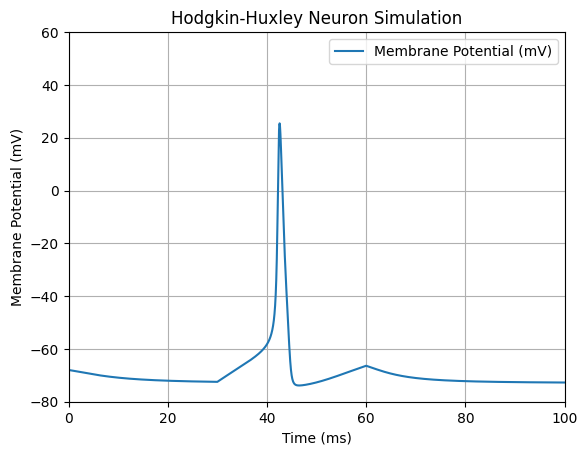

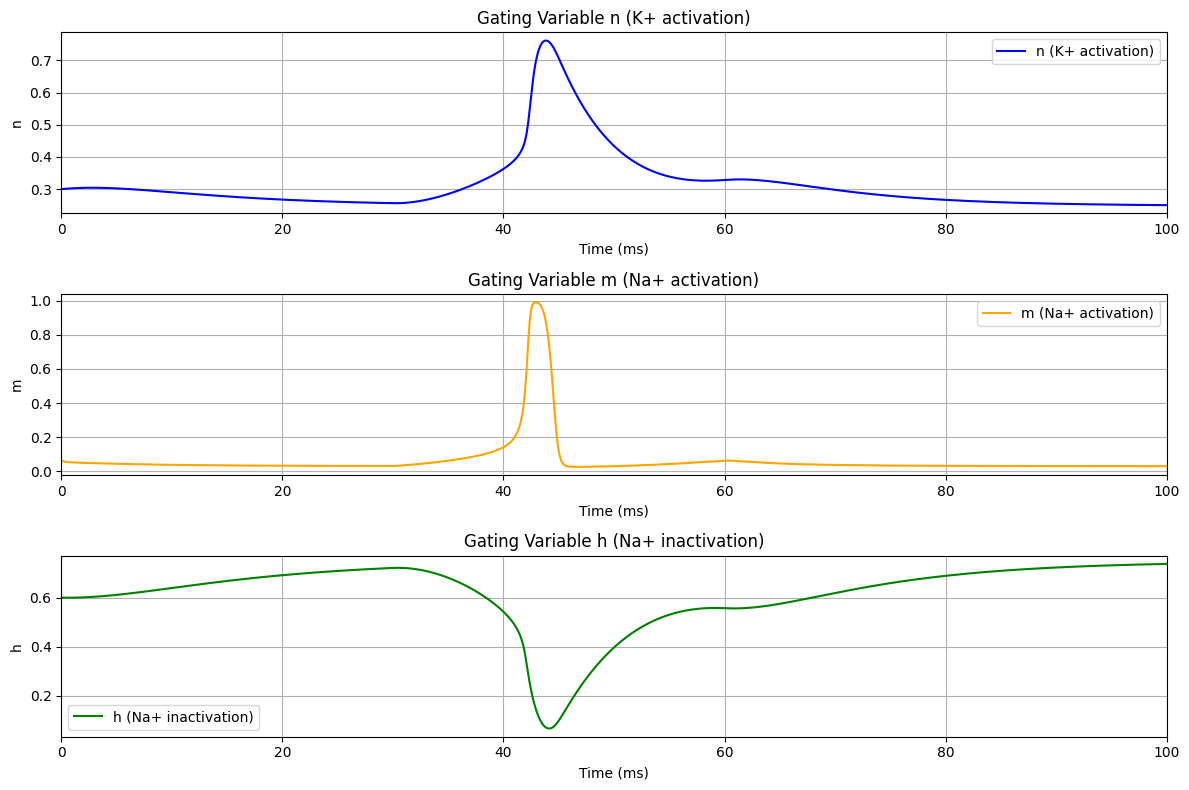

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Initial resting and Nernst potentials
# E_0 = -68.0   # -68 mV
E_Na = 54.2   # 54.2 mV
E_K = -74.7   # -74.7 mV
E_L = -65.8   # -65.8 mV

# Initial activation and inactivation parameters
n_0 = 0.3
m_0 = 0.0665
h_0 = 0.6

# Maximal conductances
G_K = 12.0     # 12 mho/cm^2
G_Na = 30.0    # 30 mho/cm^2
G_l = 0.001    # 0.001 mho/cm^2

C_m = 1.0      # 1 uF/cm^2

# calculationg intial resting potential E_0 using the Nernst equation and initial gating variables
E_0 = (G_Na * m_0**3 * h_0 * E_Na + G_K * n_0**4 * E_K + G_l * E_L) / (G_Na * m_0**3 * h_0 + G_K * n_0**4 + G_l)    
print(f"Calculated initial resting potential E_0: {E_0:.2f} mV")

# Time step and total time
dt = 0.0001      # 0.01 ms
T_total = 100.0 # 80 ms

I_ext_amp = 1.3 # 75 nA/cm^2 ( given as 75 micro ampere in the assignment, which is not possible)

t = np.arange(0, T_total, dt)
V = np.zeros_like(t)
n = np.zeros_like(t)
m = np.zeros_like(t)
h = np.zeros_like(t)

# Set initial conditions
V[0], n[0], m[0], h[0] = E_0, n_0, m_0, h_0

# Defining alpha and beta functions adjusted for absolute voltage V
 # Relative voltage for HH equations (For the original HH model, the voltage has a different )

def alpha_n(V):
    v_rel = V - E_0 
    denom = np.exp((10 - v_rel) / 10) - 1
    # Handle division by zero singularity smoothly
    return np.where(np.abs(10 - v_rel) < 1e-6, 0.1, 0.01 * (10 - v_rel) / denom)

def beta_n(V):
    v_rel = V - E_0 
    return 0.125 * np.exp(-v_rel / 80)

def alpha_m(V):
    v_rel = V - E_0 
    denom = np.exp((25 - v_rel) / 10) - 1
    # Handle division by zero singularity smoothly
    return np.where(np.abs(25 - v_rel) < 1e-6, 1.0, 0.1 * (25 - v_rel) / denom)

def beta_m(V):
    v_rel = V - E_0 
    return 4 * np.exp(-v_rel / 18)

def alpha_h(V):
    v_rel = V - E_0 
    return 0.07 * np.exp(-v_rel / 20)

def beta_h(V):
    v_rel = V - E_0 
    return 1 / (1 + np.exp((30 - v_rel) / 10))

# Derivatives
def dn_dt(n, V):
    return alpha_n(V) * (1 - n) - beta_n(V) * n

def dm_dt(m, V):
    return alpha_m(V) * (1 - m) - beta_m(V) * m

def dh_dt(h, V):
    return alpha_h(V) * (1 - h) - beta_h(V) * h

# Currents
def I_ion(V, n, m, h):
    I_K = G_K * (n**4) * (V - E_K)
    I_Na = G_Na * (m**3) * h * (V - E_Na)
    I_L = G_l * (V - E_L)
    return I_Na + I_K + I_L


def I_ext(t):
    return I_ext_amp if 30 <= t < 60 else 0.0
    #return 0

def dV_dt(V, n, m, h, t):
    # Fixed formula sign: External current depolarizes, Ionic currents hyperpolarize
    return (I_ext(t) - I_ion(V, n, m, h)) / C_m

def derivatives(V, n, m, h, t):
    return dV_dt(V, n, m, h, t), dn_dt(n, V), dm_dt(m, V), dh_dt(h, V)

# Euler method for numerical integration
for i in range(1, len(t)):
    dV, dn, dm, dh = derivatives(V[i-1], n[i-1], m[i-1], h[i-1], t[i-1])
    V[i], n[i], m[i], h[i] = V[i-1] + dV * dt, n[i-1] + dn * dt, m[i-1] + dm * dt, h[i-1] + dh * dt

print(V)
# Plotting the results in one figure with subplots
fig, axs = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axs[0].plot(t, V, label='Membrane Potential (mV)', color='black')
axs[0].set_title('Membrane Potential')
axs[0].set_ylabel('V (mV)')
axs[0].set_xlim(0, T_total)
axs[0].set_ylim(-80, 60)
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t, n, label='n (K+ activation)', color='blue')
axs[1].set_title('Gating Variable n (K+ activation)')
axs[1].set_ylabel('n')
axs[1].set_xlim(0, T_total)
axs[1].legend()
axs[1].grid(True)

axs[2].plot(t, m, label='m (Na+ activation)', color='orange')
axs[2].set_title('Gating Variable m (Na+ activation)')
axs[2].set_ylabel('m')
axs[2].set_xlim(0, T_total)
axs[2].legend()
axs[2].grid(True)

axs[3].plot(t, h, label='h (Na+ inactivation)', color='green')
axs[3].set_title('Gating Variable h (Na+ inactivation)')
axs[3].set_xlabel('Time (ms)')
axs[3].set_ylabel('h')
axs[3].set_xlim(0, T_total)
axs[3].legend()
axs[3].grid(True)

plt.tight_layout()
plt.show()